**This notebook shows how to run PixCuboid on images from a COLMAP reconstruction.**

In [1]:
%load_ext autoreload
%autoreload 2

import os
from pathlib import Path

import numpy as np
import torch
import rerun as rr
import rerun.blueprint as rrb
from omegaconf import OmegaConf

from pixloc.pixlib.datasets.base_dataset import collate
from pixloc.pixlib.datasets.cuboid_sampling import sample_cuboid_cams
from pixloc.pixlib.datasets.line_segments import read_line_segments
from pixloc.pixlib.datasets.view import read_view
from pixloc.pixlib.geometry import Camera, Pose
from pixloc.pixlib.geometry.cuboid import Cuboid
from pixloc.pixlib.utils.tensor import batch_to_device, map_tensor
from pixloc.pixlib.utils.experiments import load_experiment
from pixloc.settings import root
from pixloc.utils.colmap import read_model
from pixloc.visualization.cuboid import draw_edges
from pixloc.visualization.rerun import (
    log_camera, log_cuboid, log_image, log_points)
from pixloc.visualization.viz_2d import plot_images

os.environ['RERUN_NOTEBOOK_ASSET'] = 'inline'
torch.set_grad_enabled(False);
color_pred = torch.tensor([14, 154, 167]) / 255.

# Load the training experiment

In [2]:
exp = 'pixcuboid_scannetpp'
device = 'cuda' if torch.cuda.is_available() else 'cpu'
conf = {
    'pre_optimize_vp': True,
    'optimizer': {
        'num_iters': 15,
        'edge_cost_scale': 0.05,
        'vp_cost_scale': 40.0,
    },
}
refiner = load_experiment(exp, conf).to(device)

[06/10/2025 07:49:50 pixloc.pixlib.utils.experiments INFO] Loading checkpoint checkpoint_best.tar


# Load the COLMAP reconstruction

- The reconstruction should ideally have metric scale
- Currently, only pinhole cameras are supported

In [3]:
root_dir = root / 'assets' / 'office'
cameras, images, points3D = read_model(root_dir)

conf = OmegaConf.create({
    'grayscale': False,
    'resize': 480,
    'resize_by': 'min',
    'crop': False,
    'pad': False,
})
image_dir = root_dir / 'images'

image_data = []
for image_id in images:
    image = images[image_id]
    cam = cameras[image.camera_id]
    assert cam.model == 'PINHOLE'

    camera = Camera.from_colmap(cam)
    T_w2c = Pose.from_colmap(image)
    data = read_view(conf, image_dir / image.name, camera, T_w2c, np.empty((0, 3)), np.empty(0))

    l2D, l2D_mask = read_line_segments(image_dir / 'line_segments.npz', image.name, 100)
    data['lines2D'] = camera.normalize(l2D - 0.5).float()
    data['l2D_mask'] = torch.from_numpy(l2D_mask)

    image_data.append(data)

# Run PixCuboid

In [4]:
# Setup logging function to store the optimization steps
cuboid_opt = []
def logging_fn(**args):
    cuboid_opt.append(args['cuboid'][0].detach().cpu())
for i in range(len(refiner.extractor.scales)):
    if refiner.conf.duplicate_optimizer_per_scale:
        opt = refiner.optimizer[i]
    else:
        opt = refiner.optimizer
    opt.logging_fn = logging_fn

# Sample images
num_views = 5
data = collate(np.random.choice(image_data, num_views, replace=False).tolist())

# Sample initial cuboid
data['cuboid_init'] = sample_cuboid_cams(data['T_w2cam']).float()

# Run cuboid refiner
data = collate([data])
data_ = batch_to_device(data, device)
pred_ = refiner(data_)
pred = map_tensor(pred_, lambda x: x[0].cpu())
data = map_tensor(data_, lambda x: x[0].cpu())

## Visualize inputs

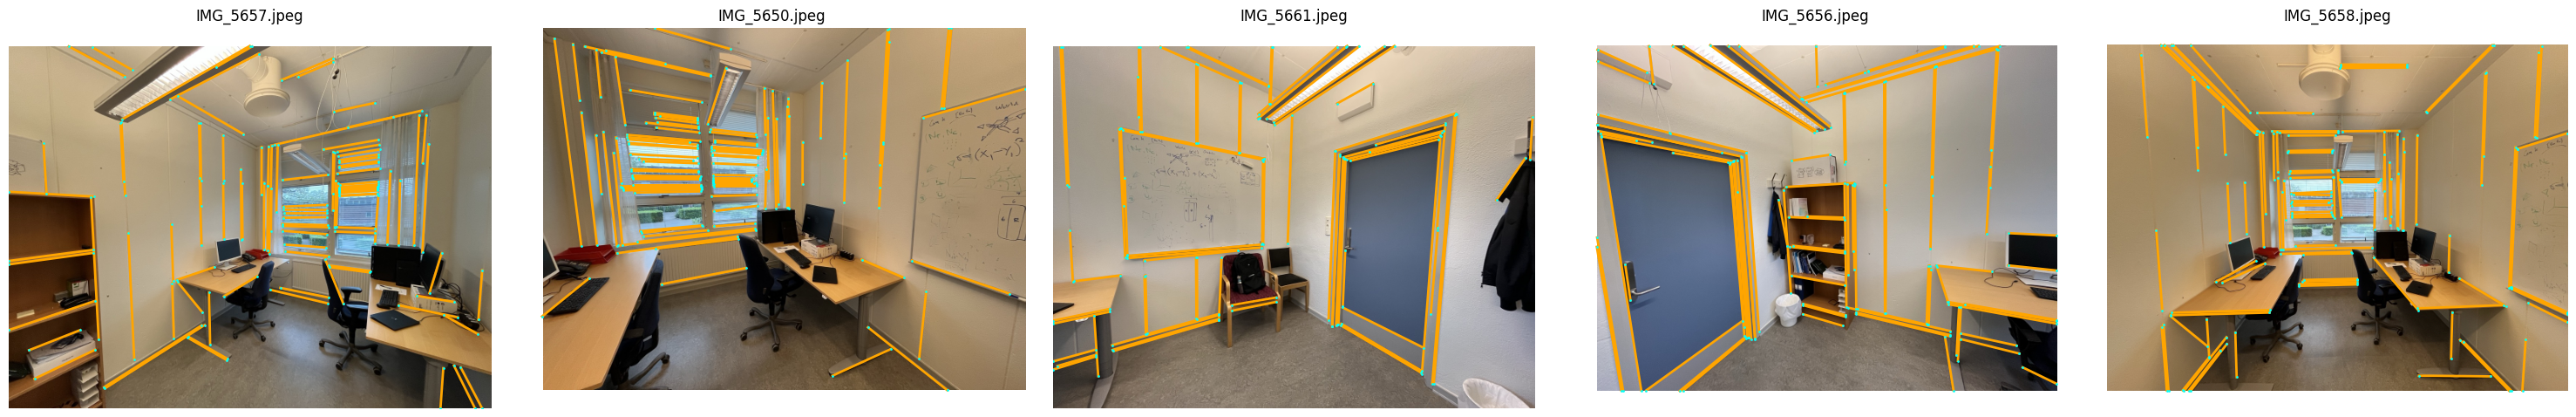

In [5]:
plot_images([i.permute(1, 2, 0) for i in data['image']],
            titles=[n[0] for n in data['name']])

try:
    from deeplsd.geometry.viz_2d import plot_lines
    plot_lines([c.denormalize(l[m]) for c, l, m in zip(data['camera'], data['lines2D'], data['l2D_mask'])],
               indices=list(range(data['lines2D'].shape[0])))
except ImportError:
    pass

## Visualize cuboid prediction

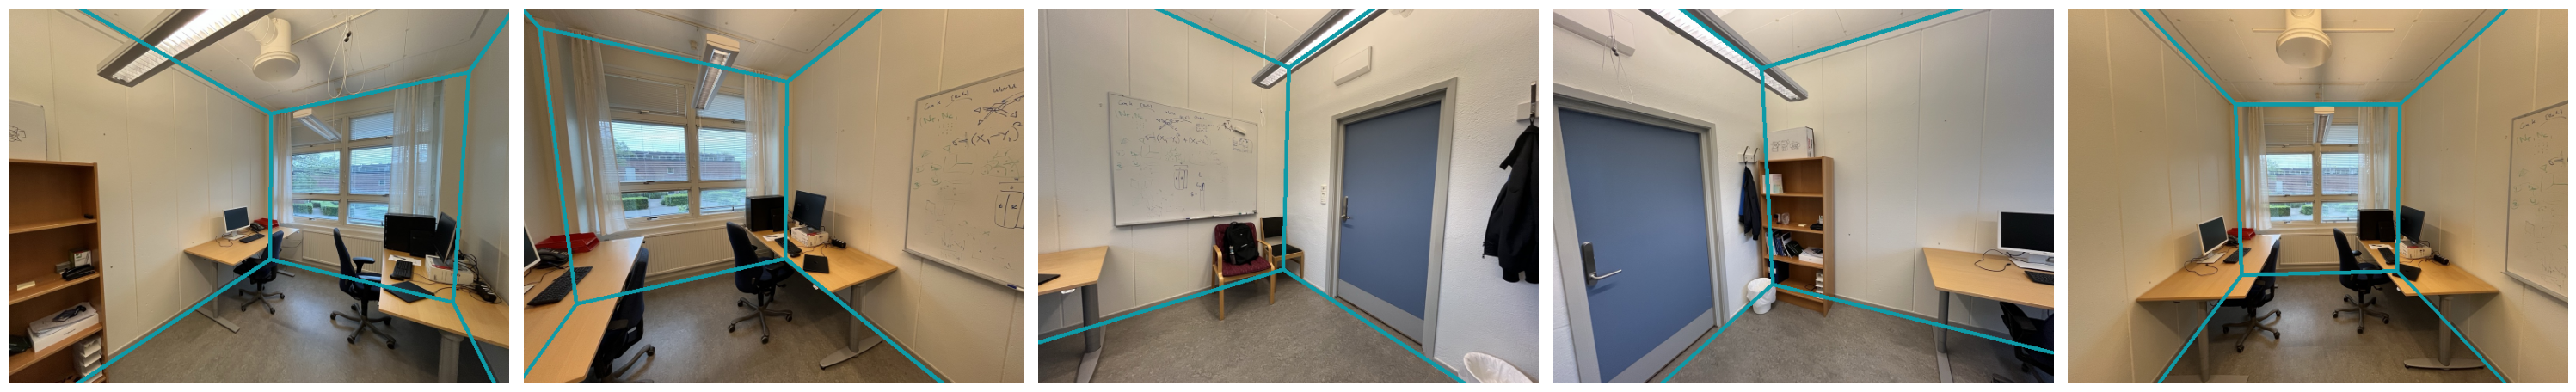

In [6]:
def mix_images(image, edge_map, color):
    return edge_map * image + (1.0 - edge_map) * torch.ones_like(image) * color[..., None, None]

edge_images = []

for image, T_w2cam, camera in zip(data['image'], data['T_w2cam'], data['camera']):
    img_edge = np.ones(image.shape[1:])
    draw_edges(cuboid_opt[-1] @ T_w2cam.inv(), camera, img_edge, 0.0, 3)
    edge_images.append(mix_images(image, torch.from_numpy(img_edge), color_pred).permute(1,2,0))

plot_images(edge_images)

## Visualize optimization steps in 3D

In [7]:
rr.init('PixCuboid COLMAP')
rr.send_blueprint(rrb.Blueprint(rrb.Spatial3DView()))

rr.set_time('step', sequence=-1)

log_cuboid('cuboid', data['cuboid_init'], color_pred)

for i in range(data['camera'].shape[0]):
    log_camera(f'camera{i}', data['camera'][i], data['T_w2cam'][i], image_plane_distance=0.2)
    log_image(f'camera{i}/image', data['image'][i].permute(1, 2, 0), opacity=0.5)

p3d = np.stack([p.xyz for p in points3D.values()])
colors = np.stack([p.rgb for p in points3D.values()])
log_points("points", p3d, colors, radii=0.02)

for i, c in enumerate(cuboid_opt):
    rr.set_time('step', sequence=i)
    log_cuboid('cuboid', c, color_pred)

rr.notebook_show(width=1024, height=768)

Viewer()